# 01_EDA — Amazon Delivery Dataset

**Input:** `amazon_delivery.csv` (raw, untouched — no feature engineering happens in this
notebook).

**Scope:**
- Load dataset
- Missing values
- Visualizations
- Correlation
- Business insights

Feature engineering (Distance, Preparation_Time, Order_Hour, etc.) is deliberately **not** done
here — that logic lives entirely in `02_Feature_Engineering.ipynb`. This notebook only looks at
the data; it never modifies or saves it.


## Step 1 — Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/amazon_delivery.csv")
print("Shape:", df.shape)
df.head()


Shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


## Step 2 — Missing Values

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  str    
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  str    
 8   Order_Time       43739 non-null  str    
 9   Pickup_Time      43739 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43739 non-null  str    
 12  Vehicle          43739 non-null  str    
 13  Area             43739 non-null  str    
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 5.3 MB


In [ ]:
df.describe()


,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time
count,43739.000000,43685.000000,43739.000000,43739.000000,43739.000000,43739.000000,43739.000000
mean,29.567137,4.633780,17.210960,70.661177,17.459031,70.821842,124.905645
std,5.815155,0.334716,7.764225,21.475005,7.342950,21.153148,51.915451
min,15.000000,1.000000,-30.902872,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.500000,12.933298,73.170283,12.985996,73.280000,90.000000
50%,30.000000,4.700000,18.551440,75.898497,18.633626,76.002574,125.000000
75%,35.000000,4.900000,22.732225,78.045359,22.785049,78.104095,160.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,270.000000


In [ ]:
df.isnull().sum()


Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

**Digging deeper than `isnull()`:** for the categorical columns, it's worth checking
`value_counts(dropna=False)` directly rather than trusting `isnull()` alone — a missing value
disguised as a string (e.g. `"NaN "` with a trailing space) won't be caught by `isnull()`, since
pandas only recognizes exact, untrimmed `"NaN"` as null by default.


In [ ]:
for col in ["Weather", "Traffic", "Vehicle", "Area", "Category"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


--- Weather ---
Weather
Fog           7440
Stormy        7374
Cloudy        7288
Sandstorms    7245
Windy         7223
Sunny         7078
NaN             91
Name: count, dtype: int64

--- Traffic ---
Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
NaN           91
Name: count, dtype: int64

--- Vehicle ---
Vehicle
motorcycle     25527
scooter        14639
van             3558
bicycle           15
Name: count, dtype: int64

--- Area ---
Area
Metropolitian     32698
Urban              9751
Other              1138
Semi-Urban          152
Name: count, dtype: int64

--- Category ---
Category
Electronics     2849
Books           2824
Jewelry         2802
Toys            2781
Skincare        2772
Snacks          2770
Outdoors        2747
Apparel         2726
Sports          2719
Grocery         2691
Pet Supplies    2690
Home            2685
Cosmetics       2677
Kitchen         2673
Clothing        2667
Shoes           2666
Name: count, dtype: int64



**Finding:** `Weather` has 91 proper nulls (caught by `isnull()`). `Traffic` also has 91 rows
that are *supposed* to be missing, but they're stored as the literal string `"NaN "` (with a
trailing space) — so `isnull()` reports **zero** missing values for `Traffic`, even though there
really are 91. This needs to be handled explicitly in the feature-engineering stage (as a string
match, not `isnull()`), otherwise those 91 rows silently become a fifth, meaningless "NaN "
traffic category instead of being dropped or imputed like the genuine nulls.

Also note: `Traffic`, `Vehicle`, and `Area` all carry a trailing space on every value (e.g.
`"Low "`, `"motorcycle "`, `"Urban "`). It's consistent across each column (not a mix of
`"Low"` and `"Low "`), so it isn't silently creating duplicate categories — but it's still worth
stripping before these columns are used as model inputs, since a couple of libraries treat
`"Low"` and `"Low "` as distinct categories.


## Step 3 — Visualizations

### 3.1 Target Variable — `Delivery_Time`

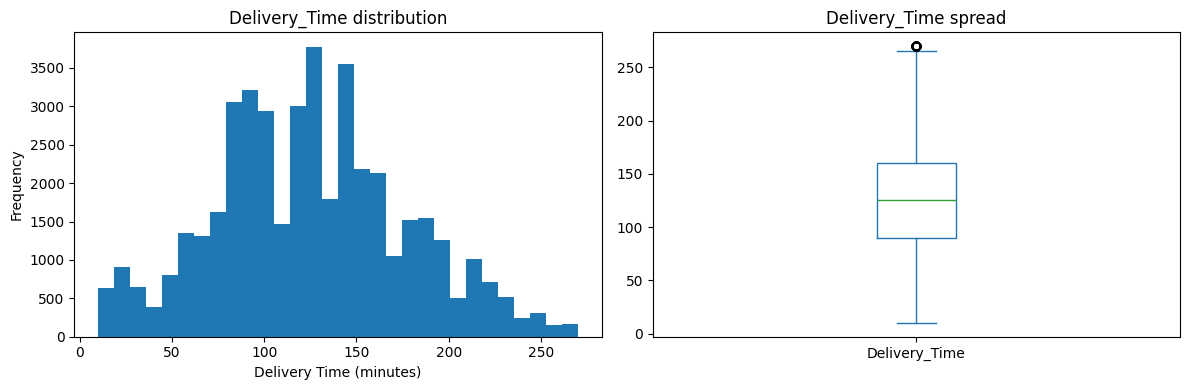

count    43739.000000
mean       124.905645
std         51.915451
min         10.000000
25%         90.000000
50%        125.000000
75%        160.000000
max        270.000000
Name: Delivery_Time, dtype: float64

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Delivery_Time"].plot(kind="hist", bins=30, ax=axes[0], title="Delivery_Time distribution")
axes[0].set_xlabel("Delivery Time (minutes)")
df["Delivery_Time"].plot(kind="box", ax=axes[1], title="Delivery_Time spread")
plt.tight_layout()
plt.show()

df["Delivery_Time"].describe()


### 3.2 Categorical Feature Distributions

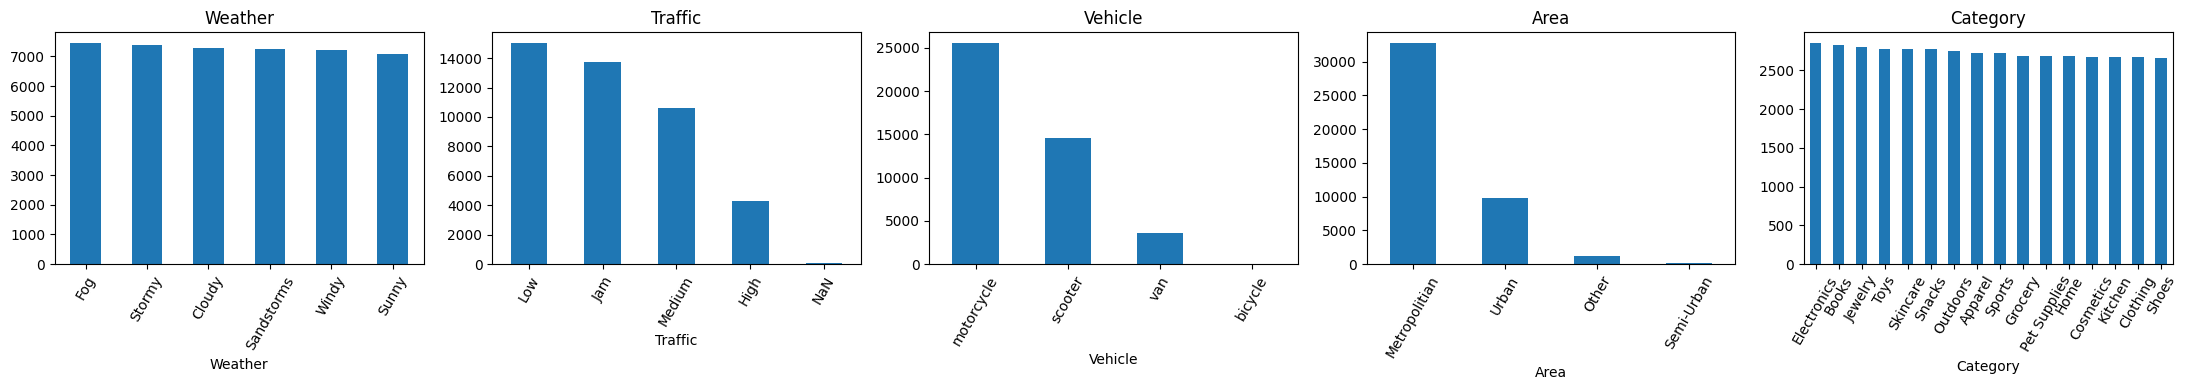

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, ["Weather", "Traffic", "Vehicle", "Area", "Category"]):
    df[col].astype(str).str.strip().value_counts().plot(kind="bar", ax=ax, title=col)
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


### 3.3 Numeric Feature Distributions — `Agent_Age`, `Agent_Rating`

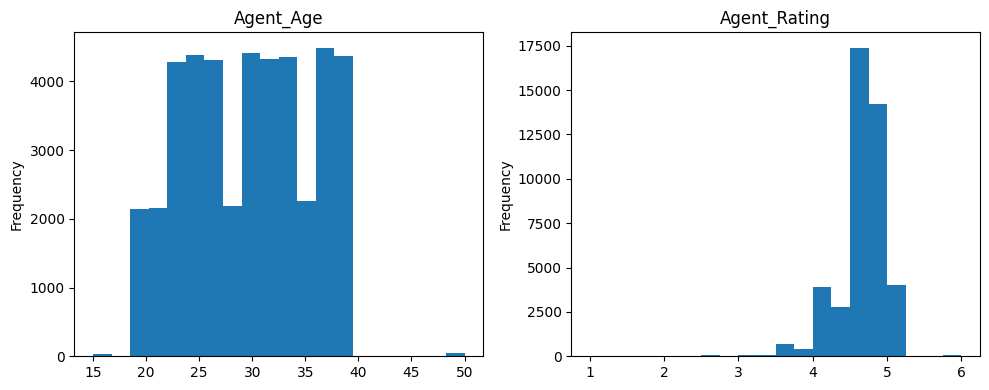

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Agent_Age"].plot(kind="hist", bins=20, ax=axes[0], title="Agent_Age")
df["Agent_Rating"].plot(kind="hist", bins=20, ax=axes[1], title="Agent_Rating")
plt.tight_layout()
plt.show()


### 3.4 Delivery Time vs. Categorical Features

Average `Delivery_Time` broken down by each categorical column — this is the first look at
which raw columns actually seem to matter, ahead of any formal correlation or modeling.


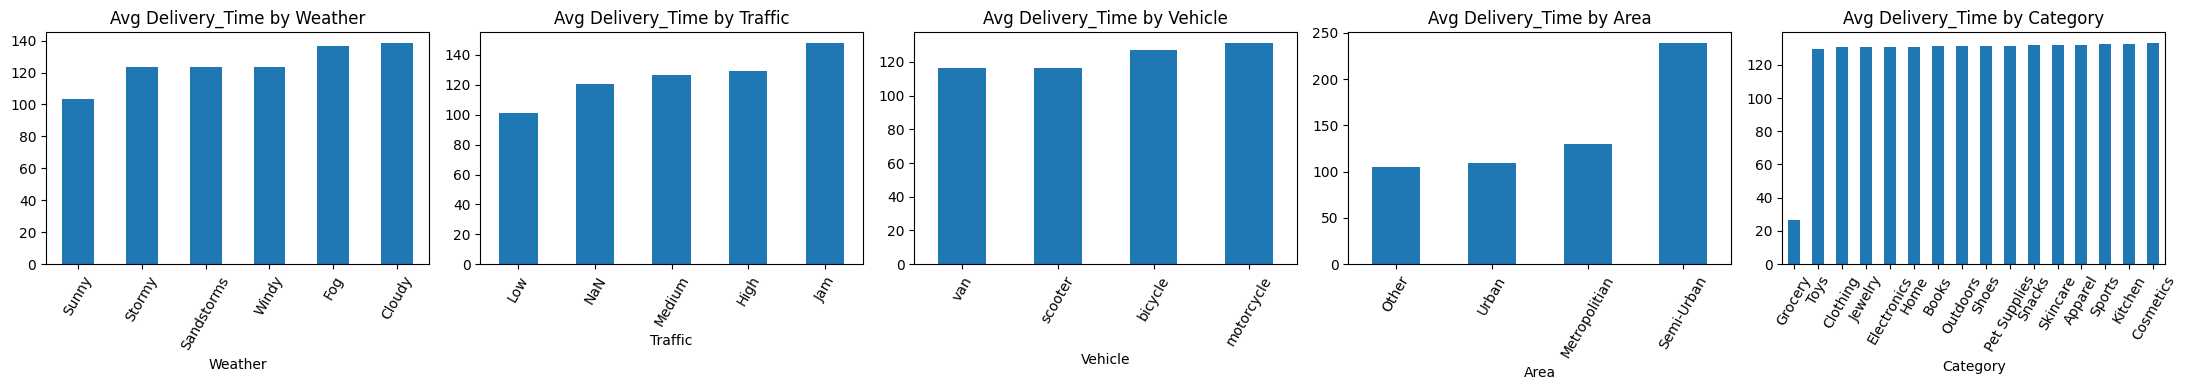

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, ["Weather", "Traffic", "Vehicle", "Area", "Category"]):
    order = df.groupby(df[col].astype(str).str.strip())["Delivery_Time"].mean().sort_values()
    order.plot(kind="bar", ax=ax, title=f"Avg Delivery_Time by {col}")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()


### 3.5 Delivery Time vs. Agent Rating / Age

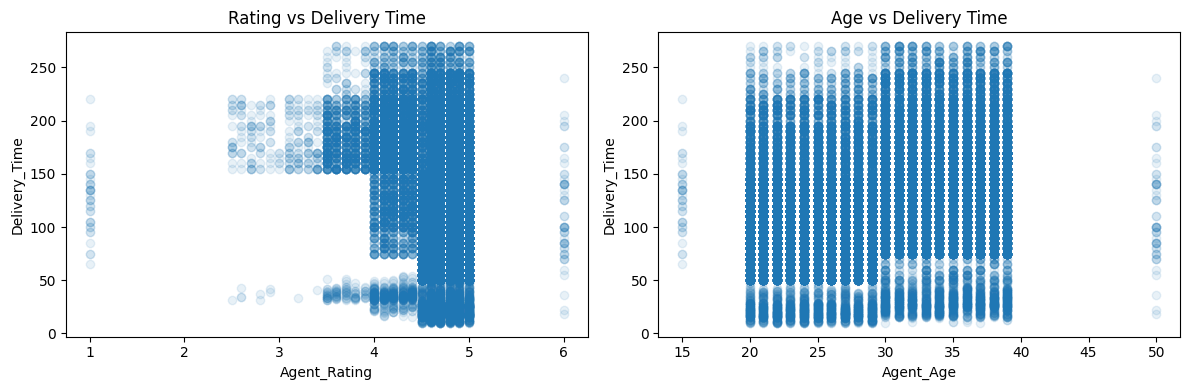

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["Agent_Rating"], df["Delivery_Time"], alpha=0.1)
axes[0].set_xlabel("Agent_Rating"); axes[0].set_ylabel("Delivery_Time"); axes[0].set_title("Rating vs Delivery Time")

axes[1].scatter(df["Agent_Age"], df["Delivery_Time"], alpha=0.1)
axes[1].set_xlabel("Agent_Age"); axes[1].set_ylabel("Delivery_Time"); axes[1].set_title("Age vs Delivery Time")
plt.tight_layout()
plt.show()


### 3.6 Geospatial Sanity Check

A quick look at the store coordinates — purely exploratory, to see whether the coordinate data
looks trustworthy before any feature (like distance) gets built from it in the next notebook.


Rows with a negative (impossible, for India) coordinate: 188 (0.43% of data)


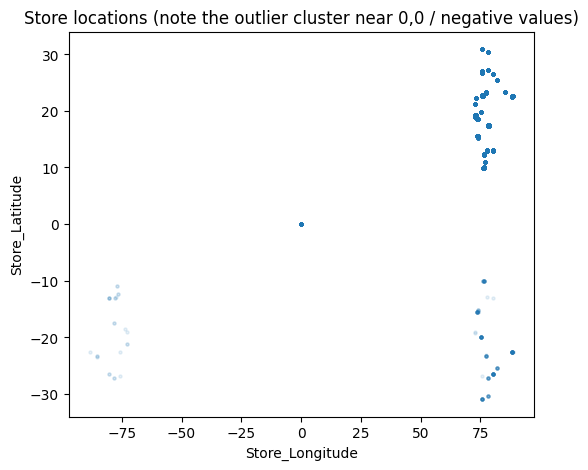

In [ ]:
neg_coords = (
    (df["Store_Latitude"] < 0) | (df["Store_Longitude"] < 0) |
    (df["Drop_Latitude"] < 0) | (df["Drop_Longitude"] < 0)
)
print("Rows with a negative (impossible, for India) coordinate:", neg_coords.sum(),
      f"({neg_coords.mean()*100:.2f}% of data)")

plt.figure(figsize=(6, 5))
plt.scatter(df["Store_Longitude"], df["Store_Latitude"], alpha=0.1, s=5)
plt.xlabel("Store_Longitude"); plt.ylabel("Store_Latitude")
plt.title("Store locations (note the outlier cluster near 0,0 / negative values)")
plt.show()


**Finding:** a small cluster of rows has negative or near-zero coordinates — physically
impossible for deliveries within India. This is a data-quality issue to clean up, not something
to fix here; `02_Feature_Engineering.ipynb` drops these rows before computing distance.


### 3.7 Order-Time Pattern (exploratory only)

`Order_Time` isn't touched or engineered here — this cell only extracts the hour *temporarily*,
purely to see whether time-of-day looks worth engineering as a feature. The dataframe itself is
not modified.


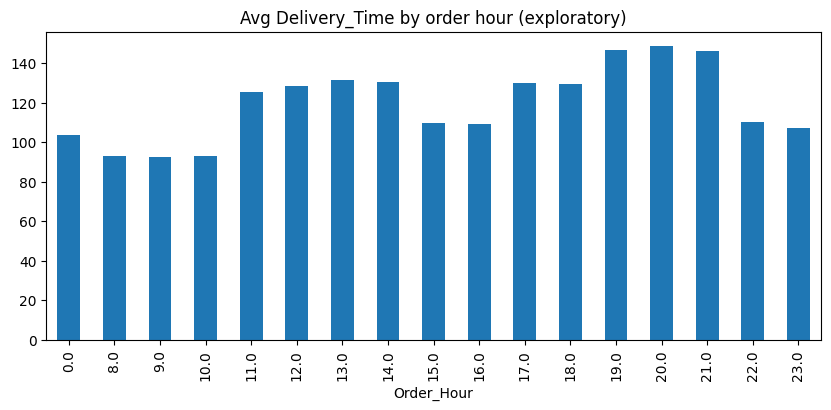

In [ ]:
_hour_preview = pd.to_datetime(df["Order_Time"], format="%H:%M:%S", errors="coerce").dt.hour
pd.DataFrame({"Order_Hour": _hour_preview, "Delivery_Time": df["Delivery_Time"]}) \
    .groupby("Order_Hour")["Delivery_Time"].mean().plot(kind="bar", figsize=(10, 4),
    title="Avg Delivery_Time by order hour (exploratory)")
plt.show()
del _hour_preview  # exploratory only — not kept in df


## Step 4 — Correlation

Correlation among the raw numeric columns. `Delivery_Time` is the target, so its row/column is
the one that matters most here.


In [ ]:
numeric_cols = ["Agent_Age", "Agent_Rating", "Delivery_Time"]
corr = df[numeric_cols].corr()
corr


,Agent_Age,Agent_Rating,Delivery_Time
Agent_Age,1.000000,-0.067939,0.254618
Agent_Rating,-0.067939,1.000000,-0.289984
Delivery_Time,0.254618,-0.289984,1.000000


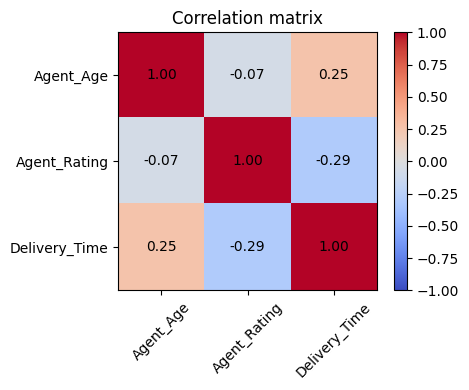

In [ ]:
plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.colorbar()
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


## Step 5 — Business Insights

Grounded directly in the numbers computed above, not generic observations:

1. **Traffic is the cleanest signal in the dataset.** Average delivery time rises
   monotonically with congestion: Low (101 min) → Medium (127) → High (129) → Jam (148) — a
   47-minute gap between the best and worst traffic condition. This alone makes `Traffic` a
   strong candidate feature.

2. **`Semi-Urban` deliveries are dramatically slower** — 239 minutes on average, roughly
   double every other area type (`Other` 105, `Urban` 109, `Metropolitian` 130). This is large
   enough to be worth flagging as a modeling consideration (e.g. `Area` will likely be one of
   the most important categorical features) rather than just background variation.

3. **`Grocery` orders behave like a completely different business** — 27 minutes average vs.
   ~130 minutes for every other category. This is almost certainly quick-commerce-style
   delivery mixed into the same dataset as standard shipping. Worth deciding explicitly whether
   to model it together with the rest or treat it as a separate segment — training one model
   across both will likely bias predictions for both groups.

4. **Traffic has a hidden data-quality issue.** 91 rows have `Traffic = "NaN "` — a literal
   string, not a real null — that `isnull()` misses entirely (see Step 2). These need to be
   handled explicitly (string match, not `isnull()`) in the feature-engineering stage.

5. **Vehicle type is counterintuitive.** `van` and `scooter` average ~116 minutes, while
   `motorcycle` is *slower* at 131 — the opposite of what you'd expect from vehicle speed
   alone. This suggests `Vehicle` is confounded with something else (e.g. which areas or
   categories each vehicle type tends to serve) rather than being a direct cause of delivery
   time by itself.

6. **Agent quality matters, modestly.** `Agent_Rating` correlates negatively with delivery
   time (-0.29) — higher-rated agents deliver faster, as expected — while `Agent_Age`
   correlates weakly positively (+0.26). Neither is a strong standalone predictor, but both are
   worth keeping as model inputs.

7. **Order timing shows a rush-hour pattern.** Orders placed around 9 AM average 93 minutes;
   orders placed around 8 PM average 149 minutes — a 56-minute gap. This supports engineering
   an hour/peak-hour feature, which is exactly what `02_Feature_Engineering.ipynb` does.

8. **Coordinate data has a small but real quality issue** — 188 rows (0.43%) have an
   impossible negative latitude/longitude. Small enough to simply drop rather than try to
   repair, which is the approach taken in the feature-engineering notebook.

**Net takeaway:** `Traffic`, `Area`, and `Category` look like the strongest predictors seen so
far; `Weather` and `Vehicle` show real but smaller/less clean effects; `Agent_Rating` and
`Agent_Age` are weak-but-real secondary signals. This ordering is worth checking against actual
feature importances once a model is trained in the next stage.
